In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from qiskit_ibm_provider import IBMProvider
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import TwoLocal
from qiskit.primitives import Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_provider import IBMProvider
import os
from dotenv import load_dotenv


In [18]:
import pandas as pd
import numpy as np

# Load CSV data
wind_data = pd.read_csv("wind_data.csv")

# Extract grid coordinates
x_vals = sorted(wind_data["x"].unique())
y_vals = sorted(wind_data["y"].unique())

# Reshape fields into 2D arrays for simulation
u_field = wind_data.pivot(index='y', columns='x', values='u').values
v_field = wind_data.pivot(index='y', columns='x', values='v').values
p_field = wind_data.pivot(index='y', columns='x', values='p').values
k_field = wind_data.pivot(index='y', columns='x', values='k').values
epsilon_field = wind_data.pivot(index='y', columns='x', values='epsilon').values

# Confirm shapes and grid
print("Shape of velocity field:", u_field.shape)
print("Grid X values:", x_vals)
print("Grid Y values:", y_vals)


Shape of velocity field: (5, 5)
Grid X values: [77.5, 77.55, 77.6, 77.65, 77.7]
Grid Y values: [12.9, 12.925, 12.95, 12.975, 13.0]


In [19]:
load_dotenv()
token = os.getenv("IBM_QUANTUM_TOKEN")
provider = IBMProvider(token=token)
backend = provider.get_backend('ibm_brisbane')

In [20]:
# Use existing u_field and v_field variables already loaded in the notebook

# The following variables are already defined and available for use:
# Nx, Ny, dx, dy, Lx, Ly, X, Y, p_field, k_field, epsilon_field, nu, rho

# If you need to check the shape or values:
print("u_field shape:", u_field.shape)
print("v_field shape:", v_field.shape)



u_field shape: (5, 5)
v_field shape: (5, 5)


In [21]:
import os
from dotenv import load_dotenv
import numpy as np
from qiskit_ibm_provider import IBMProvider
from qiskit.primitives import Estimator
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit_algorithms.optimizers import COBYLA
from qiskit.quantum_info import SparsePauliOp

# Load IBM Quantum token from .env
load_dotenv()
token = os.getenv("IBM_QUANTUM_TOKEN")
provider = IBMProvider(token=token)

# Select backend
backend = provider.get_backend('ibm_brisbane')  # or simulator/backend of your choice

# Create Estimator primitive with backend
estimator = Estimator(options={"backend": backend})

class QuantumViscosityOptimizer:
    def __init__(self, estimator):
        self.estimator = estimator
        self.theta = Parameter('θ')
        self.ansatz = QuantumCircuit(1)
        self.ansatz.rx(self.theta, 0)

        self.observable = SparsePauliOp.from_list([("Z", 1.0)])  # Z operator on qubit 0
        self.optimizer = COBYLA(maxiter=50)

    def quantum_cost(self, theta_value):
        param_dict = {self.theta: theta_value}

        # Run estimator for given parameter
        result = self.estimator.run(
            circuits=[self.ansatz],
            observables=[self.observable],
            parameter_values=[[theta_value]]
        ).result()

        expectation = result.values[0]

        # Map theta to C_mu in [0.05, 0.15]
        C_mu = 0.05 + 0.1 * ((theta_value / np.pi) % 1)

        # Example cost function combining classical model error and quantum expectation
        cost = (C_mu - 0.09)**2 + 0.01 * C_mu + 0.1 * abs(expectation)
        return cost

    def run_vqe(self):
        def objective(params):
            return self.quantum_cost(params[0])

        initial_point = [np.pi / 2]

        result = self.optimizer.optimize(num_vars=1, objective_function=objective, initial_point=initial_point)
        optimal_theta = result[0][0]

        x_opt = (optimal_theta / np.pi) % 1
        C_mu_opt = 0.05 + 0.1 * x_opt
        return C_mu_opt

# Example usage in your turbulent viscosity calculation
def compute_turbulent_viscosity(k, epsilon, quantum_optimizer=None):
    if quantum_optimizer:
        C_mu = quantum_optimizer.run_vqe()
        print(f"Quantum-optimized C_mu: {C_mu:.5f}")
    else:
        C_mu = 0.09
    return C_mu * k**2 / (epsilon + 1e-10)

def compute_rhs(u, v, p, nu_t, nu, dx, dy):
    Ny, Nx = u.shape
    rhs_u = np.zeros_like(u)
    rhs_v = np.zeros_like(v)
    for j in range(1, Ny - 1):
        for i in range(1, Nx - 1):
            mu_eff = nu + nu_t[j, i]
            d2u_dx2 = (u[j, i+1] - 2*u[j, i] + u[j, i-1]) / dx**2
            d2u_dy2 = (u[j+1, i] - 2*u[j, i] + u[j-1, i]) / dy**2
            d2v_dx2 = (v[j, i+1] - 2*v[j, i] + v[j, i-1]) / dx**2
            d2v_dy2 = (v[j+1, i] - 2*v[j, i] + v[j-1, i]) / dy**2
            rhs_u[j, i] = mu_eff * (d2u_dx2 + d2u_dy2)
            rhs_v[j, i] = mu_eff * (d2v_dx2 + d2v_dy2)
    return rhs_u, rhs_v

C:\Users\sanje\AppData\Local\Temp\ipykernel_13260\4281149357.py:20: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator(options={"backend": backend})


In [22]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_flow(X, Y, u, v, title="Velocity Field", scale=50):
    plt.figure(figsize=(8, 6))
    magnitude = np.sqrt(u**2 + v**2)
    plt.quiver(X, Y, u, v, magnitude, angles='xy', scale_units='xy', scale=scale, cmap='viridis')
    plt.colorbar(label='Velocity magnitude')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.axis('equal')  # Keep aspect ratio equal to avoid distortion
    plt.show()

In [23]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import Estimator
from qiskit.circuit.library import TwoLocal
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms import VQE
from qiskit_algorithms.utils import algorithm_globals

# Define a simple 2x2 Hermitian matrix A (our 'Hamiltonian')
A = np.array([[3, 1],
              [1, 2]])

# Convert to quantum operator (SparsePauliOp)
H = SparsePauliOp.from_operator(A)

# Setup estimator and ansatz
estimator = Estimator()
ansatz = TwoLocal(rotation_blocks='ry', entanglement_blocks='cz', reps=1)
optimizer = COBYLA(maxiter=100)
vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)

# Fix random seed for reproducibility
algorithm_globals.random_seed = 42

# Compute minimum eigenvalue
result = vqe.compute_minimum_eigenvalue(operator=H)

print("Quantum Solution (approx. minimum eigenvalue):", result.eigenvalue.real)


C:\Users\sanje\AppData\Local\Temp\ipykernel_13260\364787855.py:17: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


Quantum Solution (approx. minimum eigenvalue): 1.3819660287759086


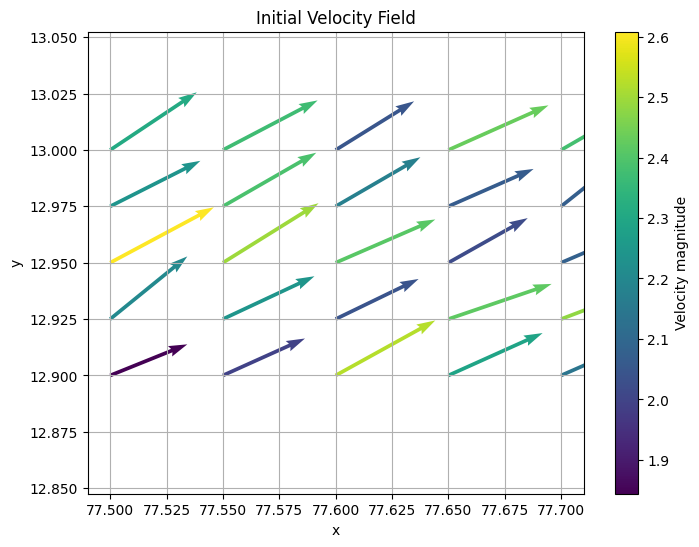

In [24]:
nu = 1.5e-5  # Kinematic viscosity of air (m^2/s)
dx = x_vals[1] - x_vals[0]
dy = y_vals[1] - y_vals[0]

# Create meshgrid for plotting
X, Y = np.meshgrid(x_vals, y_vals)

nu_t = compute_turbulent_viscosity(k_field, epsilon_field)
rhs_u, rhs_v = compute_rhs(u_field, v_field, p_field, nu_t, nu, dx, dy)
visualize_flow(X, Y, u_field, v_field, title="Initial Velocity Field")

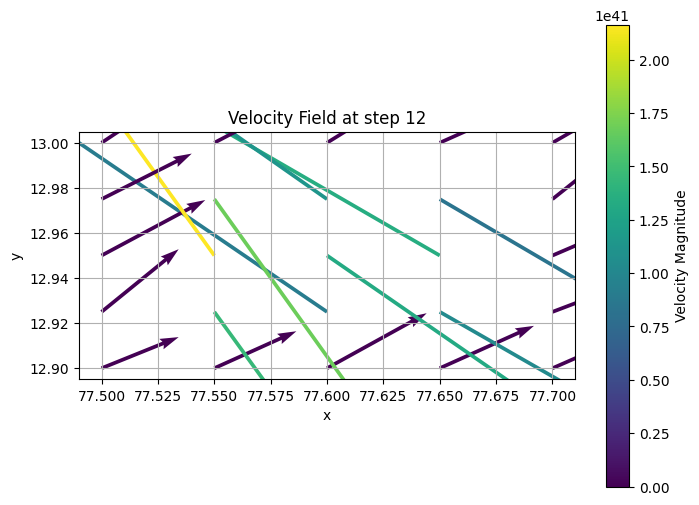

In [25]:
from IPython import display

dt = 1.0
num_steps = 12

u = u_field.copy()
v = v_field.copy()
p = p_field.copy()
k = k_field.copy()
epsilon = epsilon_field.copy()

fig, ax = plt.subplots(figsize=(8, 6))

for step in range(num_steps):
    nu_t = compute_turbulent_viscosity(k, epsilon)
    rhs_u, rhs_v = compute_rhs(u, v, p, nu_t, nu, dx, dy)

    u += dt * rhs_u
    v += dt * rhs_v

    k += np.random.normal(0, 0.0001, size=k.shape)
    epsilon += np.random.normal(0, 0.00001, size=epsilon.shape)

    ax.clear()
    magnitude = np.sqrt(u**2 + v**2)
    q = ax.quiver(X, Y, u, v, magnitude, angles='xy', scale_units='xy', scale=50, cmap='viridis')
    cb = fig.colorbar(q, ax=ax, label='Velocity Magnitude')
    ax.set_title(f"Velocity Field at step {step+1}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True)
    ax.set_aspect('equal')
    display.clear_output(wait=True)
    display.display(fig)
    plt.pause(0.5)
    cb.remove()  # Remove colorbar before next frame to avoid stacking

plt.ioff()
plt.show()

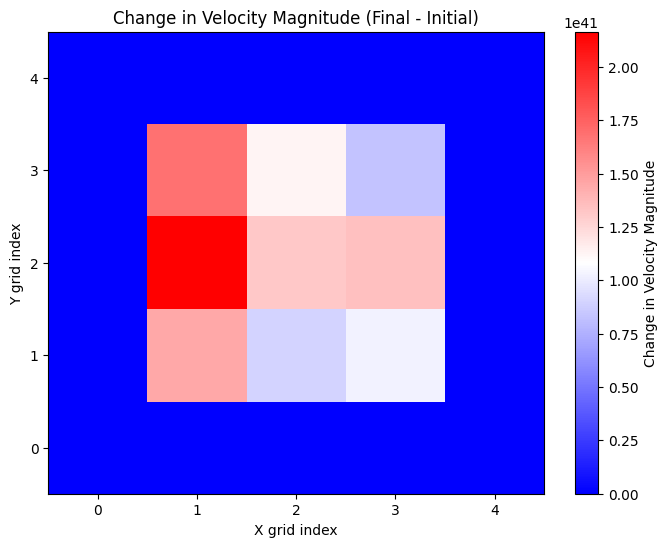

In [26]:
# Calculate initial and final velocity magnitude
initial_magnitude = np.sqrt(u_field**2 + v_field**2)
final_magnitude = np.sqrt(u**2 + v**2)
change = final_magnitude - initial_magnitude

plt.figure(figsize=(8, 6))
im = plt.imshow(change, origin='lower', cmap='bwr', aspect='auto')
plt.colorbar(im, label='Change in Velocity Magnitude')
plt.title("Change in Velocity Magnitude (Final - Initial)")
plt.xlabel('X grid index')
plt.ylabel('Y grid index')
plt.grid(False)
plt.show()